
# Smart Nursery Guardian

Build by Team 6 Members:

- `Mohamed Ibrahim - 7131E`
- `Pilopateer Hani - 7129E`
- `Tharaa Mohamed - 7005E`

This notebook is configured **only** for the Smart Nursery Guardian project classes:

- `Hungry`
- `Tired`
- `Discomfort`

In [ ]:
import numpy as np
import pandas as pd

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/bhoomikavalani/donateacrycorpusfeaturesdataset/donateacry-corpus_features_final.csv


# `1. Imports + 3-class configuration`

In [ ]:
import re
import json
import platform
from pathlib import Path
from typing import Dict, List, Tuple, Any

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (train_test_split, StratifiedKFold, RandomizedSearchCV, cross_validate)
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection importSelectKBest, f_classif
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier)
from sklearn.neighbors import KNeighborsClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, RandomOverSampler
import joblib

RANDOM_STATE = 42
TEST_SIZE = 0.20
CV_FOLDS = 5

# PROJECT TASK: 3-class ONLY
PROJECT_TASK = "3-class"
CLASS_NAMES = ["hungry", "tired", "discomfort"]

# Kaggle dataset discovery
INPUT_ROOT = Path("/kaggle/input")
DATASET_NAME_HINT = "donate-a-cry-corpus-features-dataset"

supported_suffixes = {".csv", ".xlsx", ".xls", ".parquet"}

candidate_files = [
    p for p in INPUT_ROOT.rglob("*")
    if p.is_file()
    and p.suffix.lower() in supported_suffixes
    and (
        "donate" in str(p).lower()
        or "acry" in str(p).lower()
        or "cry" in str(p).lower()
    )
]

if not candidate_files:
    raise FileNotFoundError(
        "Could not find the Donate-a-Cry feature dataset under /kaggle/input/.\n"
        "In Kaggle, add the dataset named 'donate-a-cry-corpus-features-dataset' "
        "to the notebook, then rerun this cell."
    )

preferred_files = [
    p for p in candidate_files
    if "donateacrycorpusfeaturesdataset" in p.name.lower()
    or "donate-a-cry-corpus-features-dataset" in str(p).lower()
]

DATA_PATH = (preferred_files or candidate_files)[0]
MODEL_OUTPUT_PATH = Path("/kaggle/working/smart_nursery_guardian_3class_best_model.pkl")
METRICS_OUTPUT_PATH = Path("/kaggle/working/smart_nursery_guardian_3class_metrics.json")

print("Python:", platform.python_version())
print("Platform:", platform.platform())
print("Dataset:", DATA_PATH)
print("Project classes:", CLASS_NAMES)

Python: 3.12.13
Platform: Linux-6.12.90+-x86_64-with-glibc2.35
Dataset: /kaggle/input/datasets/bhoomikavalani/donateacrycorpusfeaturesdataset/donateacry-corpus_features_final.csv
Project classes: ['hungry', 'tired', 'discomfort']


# `2. Robust dataset loading + 3-class label normalization`


In [ ]:
KNOWN_LABEL_NAME_HINTS = [
    "label", "class", "target", "reason", "cry_reason",
    "cryreason", "category", "status", "need", "output"
]

KNOWN_ID_HINTS = [
    "id", "index", "unnamed", "file", "filename", "path", "audio", "name"
]

# Only the project labels are valid training labels.
PROJECT_NUMERIC_CLASS_MAP = {
    2: "discomfort",
    3: "hungry",
    4: "tired",
}

PROJECT_TEXT_ALIASES = {
    "discomfort": "discomfort",
    "hungry": "hungry",
    "hunger": "hungry",
    "tired": "tired",
    "fatigue": "tired",
    "sleepy": "tired",
}

def normalize_text(x: Any) -> str:
    if pd.isna(x):
        return ""
    s = str(x).strip().lower()
    s = s.replace("_", " ").replace("-", " ")
    s = re.sub(r"\s+", " ", s)
    return s

def find_target_column(df: pd.DataFrame) -> str:
    # 1) exact-ish semantic hints
    normalized = {c: normalize_text(c) for c in df.columns}
    for c, n in normalized.items():
        if any(h == n or h in n for h in KNOWN_LABEL_NAME_HINTS):
            return c

    # 2) detect a numeric column containing ONLY project numeric IDs
    for c in df.columns:
        vals = df[c].dropna().unique()
        if len(vals) == 0:
            continue

        if pd.api.types.is_numeric_dtype(df[c]):
            try:
                uniq = set(pd.Series(vals).astype(int).tolist())
            except Exception:
                continue

            # At least two project classes must be present.
            if uniq.issubset(set(PROJECT_NUMERIC_CLASS_MAP.keys())) and len(uniq) >= 2:
                return c

    # 3) detect a text column containing at least two project labels
    project_labels = set(PROJECT_TEXT_ALIASES.values())
    for c in df.columns:
        vals = set(df[c].dropna().map(normalize_text).unique())
        mapped_vals = {
            PROJECT_TEXT_ALIASES[v]
            for v in vals
            if v in PROJECT_TEXT_ALIASES
        }
        if len(mapped_vals & project_labels) >= 2:
            return c

    raise ValueError(
        "Could not infer the target/label column. "
        "Inspect df_raw.columns and set TARGET_COLUMN manually."
    )

def load_table(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Dataset not found: {path.resolve()}")

    suffix = path.suffix.lower()

    if suffix == ".csv":
        return pd.read_csv(path)
    if suffix in {".xlsx", ".xls"}:
        return pd.read_excel(path)
    if suffix == ".parquet":
        return pd.read_parquet(path)

    raise ValueError(f"Unsupported dataset format: {suffix}")

df_raw = load_table(DATA_PATH)

print("Raw shape:", df_raw.shape)
display(df_raw.head())

TARGET_COLUMN = find_target_column(df_raw)
print("Detected target column:", TARGET_COLUMN)

def normalize_project_labels(series: pd.Series) -> pd.Series:
    result = pd.Series(np.nan, index=series.index, dtype="object")

    # Numeric labels: keep ONLY 2, 3, 4.
    if pd.api.types.is_numeric_dtype(series):
        numeric = pd.to_numeric(series, errors="coerce")
        result = numeric.map(PROJECT_NUMERIC_CLASS_MAP)
        return result

    # Text labels: keep ONLY the project aliases.
    normalized = series.map(normalize_text)
    return normalized.map(PROJECT_TEXT_ALIASES)

df_raw["__label__"] = normalize_project_labels(df_raw[TARGET_COLUMN])

print("\nOriginal/raw label distribution:")
display(
    df_raw["__label__"]
    .value_counts(dropna=False)
    .rename("count")
    .to_frame()
)

# Keep ONLY Hungry / Tired / Discomfort.
df = df_raw[df_raw["__label__"].isin(CLASS_NAMES)].copy()
df = df.reset_index(drop=True)

print("\nProject task: 3-class only")
print("Classes used:", CLASS_NAMES)
print("Shape after 3-class filter:", df.shape)

display(
    df["__label__"]
    .value_counts()
    .reindex(CLASS_NAMES)
    .rename("count")
    .to_frame()
)

missing_project_classes = [
    c for c in CLASS_NAMES
    if df["__label__"].eq(c).sum() == 0
]

if missing_project_classes:
    raise ValueError(
        "One or more required project classes are missing from the loaded dataset: "
        f"{missing_project_classes}"
    )

Raw shape: (457, 27)


,Cry_Audio_File,Cry_Reason,Amplitude_Envelope_Mean,RMS_Mean,ZCR_Mean,STFT_Mean,SC_Mean,SBAN_Mean,SCON_Mean,MFCCs13Mean,...,MFCCs4,MFCCs5,MFCCs6,MFCCs7,MFCCs8,MFCCs9,MFCCs10,MFCCs11,MFCCs12,MFCCs13
0,/Users/mac/Desktop/Smart_Cradle/donateacry_cor...,0,0.028202,0.011050,0.098990,0.102389,1264.335599,519.101121,26.821807,-48.271230,...,-15.073559,10.004257,-30.088297,-18.766724,8.679635,-2.352078,-7.746244,-3.096202,-4.715273,-3.918095
1,/Users/mac/Desktop/Smart_Cradle/donateacry_cor...,0,0.021071,0.006951,0.115383,0.050369,1268.608766,575.457549,25.881312,-49.861237,...,-10.316871,-0.607061,-25.927773,-4.430356,-4.619092,-22.430754,-4.303273,0.172620,-11.258208,-3.497785
2,/Users/mac/Desktop/Smart_Cradle/donateacry_cor...,0,0.029967,0.010904,0.116663,0.100042,1546.578200,699.626649,26.594715,-49.541706,...,-22.161522,2.070754,-26.675592,3.294869,7.788799,-21.903955,-5.744544,4.150358,-11.718720,-6.870083
3,/Users/mac/Desktop/Smart_Cradle/donateacry_cor...,0,0.027163,0.010520,0.085081,0.140766,1089.415328,668.895951,25.608310,-44.275997,...,-1.704598,0.226281,-29.814095,-14.937744,-11.162116,-21.503994,-7.501309,-7.856627,-15.119538,-3.970483
4,/Users/mac/Desktop/Smart_Cradle/donateacry_cor...,0,0.016663,0.006577,0.067108,0.057629,1017.610932,700.682410,28.196010,-51.325264,...,7.812110,-9.098410,-34.050182,-9.673841,-11.780775,-24.962975,-7.697065,-9.014325,-15.366213,-2.237437


Detected target column: Cry_Reason

Original/raw label distribution:


,count
__label__,
hungry,382
discomfort,27
NaN,24
tired,24



Project task: 3-class only
Classes used: ['hungry', 'tired', 'discomfort']
Shape after 3-class filter: (433, 28)


,count
__label__,
hungry,382
tired,24
discomfort,27


# `3. Build a clean numeric feature matrix`

In [ ]:
def looks_like_id_column(name: str) -> bool:
    n = normalize_text(name)
    return (
        n.startswith("unnamed")
        or n in {"id", "index"}
        or any(token == part for token in KNOWN_ID_HINTS for part in n.split())
        or n in {"file name", "filename", "file path", "audio path"}
    )

def build_feature_matrix(df: pd.DataFrame, target_col: str) -> Tuple[pd.DataFrame, pd.Series, List[str]]:
    y = df["__label__"].copy()

    work = df.drop(columns=[target_col, "__label__"], errors="ignore").copy()

    # Remove obvious metadata / identifiers.
    drop_cols = [c for c in work.columns if looks_like_id_column(c)]
    work = work.drop(columns=drop_cols, errors="ignore")

    # Keep only numeric columns. Convert numeric-looking strings when possible.
    for c in work.columns:
        if not pd.api.types.is_numeric_dtype(work[c]):
            converted = pd.to_numeric(work[c], errors="coerce")
            if converted.notna().mean() >= 0.90:
                work[c] = converted

    X = work.select_dtypes(include=[np.number]).copy()

    # Remove all-empty / constant columns up front.
    X = X.dropna(axis=1, how="all")
    nunique = X.nunique(dropna=True)
    X = X.loc[:, nunique > 1]

    # Replace infinite values with NaN; the pipeline will impute them.
    X = X.replace([np.inf, -np.inf], np.nan)

    feature_names = X.columns.tolist()

    if len(feature_names) < 2:
        raise ValueError(
            "Fewer than 2 usable numeric feature columns were found. "
            "Inspect df.columns and adjust the metadata/feature filtering."
        )

    return X, y, feature_names

X, y, FEATURE_NAMES = build_feature_matrix(df, TARGET_COLUMN)

print("Feature matrix:", X.shape)
print("Feature count:", len(FEATURE_NAMES))
print("Features:")
print(FEATURE_NAMES)

Feature matrix: (433, 25)
Feature count: 25
Features:
['Amplitude_Envelope_Mean', 'RMS_Mean', 'ZCR_Mean', 'STFT_Mean', 'SC_Mean', 'SBAN_Mean', 'SCON_Mean', 'MFCCs13Mean', 'delMFCCs13', 'del2MFCCs13', 'MelSpec', 'MFCCs20', 'MFCCs1', 'MFCCs2', 'MFCCs3', 'MFCCs4', 'MFCCs5', 'MFCCs6', 'MFCCs7', 'MFCCs8', 'MFCCs9', 'MFCCs10', 'MFCCs11', 'MFCCs12', 'MFCCs13']


# `4. Data quality checks`

Missing values per feature (top):


,missing_count
Amplitude_Envelope_Mean,0
RMS_Mean,0
ZCR_Mean,0
STFT_Mean,0
SC_Mean,0
SBAN_Mean,0
SCON_Mean,0
MFCCs13Mean,0
delMFCCs13,0
del2MFCCs13,0



Class counts:


,count
__label__,
hungry,382
tired,24
discomfort,27



Class proportions:


,percent
__label__,
hungry,88.22
tired,5.54
discomfort,6.24


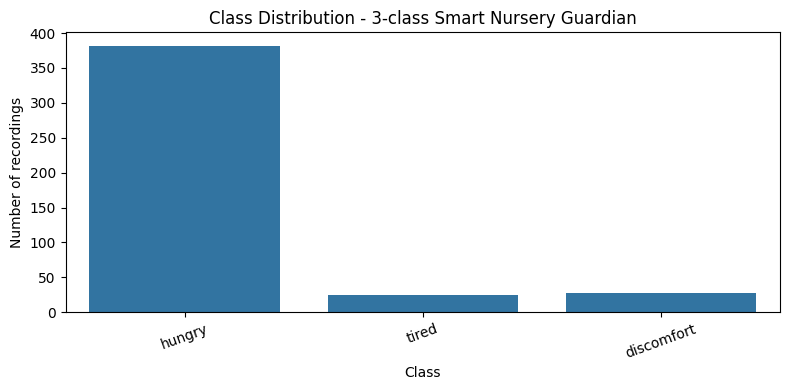

In [ ]:
print("Missing values per feature (top):")
missing = X.isna().sum().sort_values(ascending=False)
display(missing.head(15).rename("missing_count").to_frame())

print("\nClass counts:")
display(y.value_counts().reindex(CLASS_NAMES).rename("count").to_frame())

print("\nClass proportions:")
display((y.value_counts(normalize=True).reindex(CLASS_NAMES) * 100).round(2).rename("percent").to_frame())

plt.figure(figsize=(8, 4))
sns.countplot(x=y, order=CLASS_NAMES)
plt.title("Class Distribution - 3-class Smart Nursery Guardian")
plt.xlabel("Class")
plt.ylabel("Number of recordings")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


# `5. Leakage-safe split`

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

print("\nTrain class distribution:")
display(y_train.value_counts().reindex(CLASS_NAMES).rename("count").to_frame())

print("\nTest class distribution:")
display(y_test.value_counts().reindex(CLASS_NAMES).rename("count").to_frame())

Train: (346, 25)
Test : (87, 25)

Train class distribution:


,count
__label__,
hungry,305
tired,19
discomfort,22



Test class distribution:


,count
__label__,
hungry,77
tired,5
discomfort,5



## 6. Candidate models

The benchmark includes models that are strong for small tabular audio-feature datasets:

- Random Forest
- Extra Trees
- RBF SVM
- KNN
- Logistic Regression
- HistGradientBoosting

For imbalanced data, SMOTE is performed **inside each CV training fold** rather than before CV. Scaling and imputation are also inside the pipeline.

In [ ]:
N_FEATURES = X_train.shape[1]
SMOTE_K = max(1, min(3, int(y_train.value_counts().min()) - 1))

def make_pipeline(model, sampler="smote", scaler="standard", select_k=None):
    steps = [
        ("imputer", SimpleImputer(strategy="median")),
    ]

    if scaler == "standard":
        steps.append(("scaler", StandardScaler()))
    elif scaler == "robust":
        steps.append(("scaler", RobustScaler()))
    elif scaler in (None, "none"):
        pass
    else:
        raise ValueError("Unknown scaler.")

    if select_k is not None:
        steps.append((
            "selector",
            SelectKBest(score_func=f_classif, k=select_k)
        ))

    if sampler == "smote":
        steps.append(("sampler", SMOTE(
            random_state=RANDOM_STATE,
            k_neighbors=SMOTE_K
        )))
    elif sampler == "ros":
        steps.append(("sampler", RandomOverSampler(
            random_state=RANDOM_STATE
        )))
    elif sampler == "none":
        pass
    else:
        raise ValueError("Unknown sampler.")

    steps.append(("model", model))

    return ImbPipeline(steps=steps)

candidate_searches = {
    "RandomForest": (
        make_pipeline(
            RandomForestClassifier(
                random_state=RANDOM_STATE,
                n_jobs=-1,
                class_weight=None
            ),
            sampler="smote",
            scaler="none"
        ),
        {
            "sampler": [
                SMOTE(random_state=RANDOM_STATE, k_neighbors=SMOTE_K),
                RandomOverSampler(random_state=RANDOM_STATE)
            ],
            "model__n_estimators": [300, 500, 800, 1200],
            "model__max_depth": [None, 6, 10, 16, 24],
            "model__min_samples_split": [2, 4, 6, 10],
            "model__min_samples_leaf": [1, 2, 4],
            "model__max_features": ["sqrt", "log2", 0.7, 1.0],
            "model__class_weight": [None, "balanced", "balanced_subsample"],
        }
    ),

    "ExtraTrees": (
        make_pipeline(
            ExtraTreesClassifier(
                random_state=RANDOM_STATE,
                n_jobs=-1
            ),
            sampler="smote",
            scaler="none"
        ),
        {
            "sampler": [
                SMOTE(random_state=RANDOM_STATE, k_neighbors=SMOTE_K),
                RandomOverSampler(random_state=RANDOM_STATE)
            ],
            "model__n_estimators": [300, 500, 800, 1200],
            "model__max_depth": [None, 8, 12, 20, 30],
            "model__min_samples_split": [2, 4, 8],
            "model__min_samples_leaf": [1, 2, 4],
            "model__max_features": ["sqrt", "log2", 0.7, 1.0],
            "model__class_weight": [None, "balanced"],
        }
    ),

    "SVM_RBF": (
        make_pipeline(
            SVC(
                kernel="rbf",
                probability=True,
                random_state=RANDOM_STATE,
                class_weight=None
            ),
            sampler="smote",
            scaler="standard"
        ),
        {
            "sampler": [
                SMOTE(random_state=RANDOM_STATE, k_neighbors=SMOTE_K),
                RandomOverSampler(random_state=RANDOM_STATE)
            ],
            "model__C": np.logspace(-2, 3, 12),
            "model__gamma": ["scale", "auto"] + list(np.logspace(-4, 0, 8)),
            "model__class_weight": [None, "balanced"],
        }
    ),

    "KNN": (
        make_pipeline(
            KNeighborsClassifier(),
            sampler="smote",
            scaler="standard"
        ),
        {
            "sampler": [
                SMOTE(random_state=RANDOM_STATE, k_neighbors=SMOTE_K),
                RandomOverSampler(random_state=RANDOM_STATE)
            ],
            "model__n_neighbors": [3, 5, 7, 9, 11, 15, 21],
            "model__weights": ["uniform", "distance"],
            "model__p": [1, 2],
        }
    ),

    "LogisticRegression": (
        make_pipeline(
            LogisticRegression(
                max_iter=5000,
                random_state=RANDOM_STATE
            ),
            sampler="smote",
            scaler="standard"
        ),
        {
            "sampler": [
                SMOTE(random_state=RANDOM_STATE, k_neighbors=SMOTE_K),
                RandomOverSampler(random_state=RANDOM_STATE)
            ],
            "model__C": np.logspace(-3, 3, 12),
            "model__solver": ["lbfgs", "liblinear"],
            "model__class_weight": [None, "balanced"],
        }
    ),

    "HistGradientBoosting": (
        make_pipeline(
            HistGradientBoostingClassifier(
                random_state=RANDOM_STATE
            ),
            sampler="smote",
            scaler="none"
        ),
        {
            "sampler": [
                SMOTE(random_state=RANDOM_STATE, k_neighbors=SMOTE_K),
                RandomOverSampler(random_state=RANDOM_STATE)
            ],
            "model__learning_rate": [0.02, 0.05, 0.08, 0.12],
            "model__max_iter": [100, 200, 400],
            "model__max_leaf_nodes": [7, 15, 31],
            "model__l2_regularization": [0.0, 0.1, 1.0, 5.0],
        }
    ),
}

print("SMOTE k_neighbors =", SMOTE_K)
print("Candidates:", list(candidate_searches))

SMOTE k_neighbors = 3
Candidates: ['RandomForest', 'ExtraTrees', 'SVM_RBF', 'KNN', 'LogisticRegression', 'HistGradientBoosting']


# `7. Hyperparameter search`

In [ ]:
cv = StratifiedKFold(
    n_splits=CV_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE
)

search_results = []
search_objects = {}

for name, (pipe, param_dist) in candidate_searches.items():
    print(f"\n===== {name} =====")

    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_dist,
        n_iter=30,
        scoring={
            "accuracy": "accuracy",
            "balanced_accuracy": "balanced_accuracy",
            "f1_macro": "f1_macro",
        },
        refit="accuracy",
        cv=cv,
        n_jobs=-1,
        verbose=1,
        random_state=RANDOM_STATE,
        return_train_score=False
    )

    search.fit(X_train, y_train)
    search_objects[name] = search

    best_idx = search.best_index_
    row = {
        "model": name,
        "cv_accuracy": search.cv_results_["mean_test_accuracy"][best_idx],
        "cv_balanced_accuracy": search.cv_results_["mean_test_balanced_accuracy"][best_idx],
        "cv_f1_macro": search.cv_results_["mean_test_f1_macro"][best_idx],
        "best_params": search.best_params_,
    }
    search_results.append(row)

results_df = pd.DataFrame(search_results).sort_values(
    ["cv_accuracy", "cv_f1_macro", "cv_balanced_accuracy"],
    ascending=False
).reset_index(drop=True)

display(results_df[[
    "model", "cv_accuracy", "cv_balanced_accuracy", "cv_f1_macro"
]])

print("\nBest CV model:", results_df.loc[0, "model"])
display(results_df.loc[0, "best_params"])


===== RandomForest =====
Fitting 5 folds for each of 30 candidates, totalling 150 fits

===== ExtraTrees =====
Fitting 5 folds for each of 30 candidates, totalling 150 fits

===== SVM_RBF =====
Fitting 5 folds for each of 30 candidates, totalling 150 fits

===== KNN =====
Fitting 5 folds for each of 30 candidates, totalling 150 fits

===== LogisticRegression =====
Fitting 5 folds for each of 30 candidates, totalling 150 fits

===== HistGradientBoosting =====
Fitting 5 folds for each of 30 candidates, totalling 150 fits


,model,cv_accuracy,cv_balanced_accuracy,cv_f1_macro
0,SVM_RBF,0.881532,0.333333,0.312343
1,ExtraTrees,0.878675,0.332240,0.311795
2,RandomForest,0.875818,0.331148,0.311238
3,HistGradientBoosting,0.870062,0.328962,0.310124
4,KNN,0.748489,0.447705,0.404735
5,LogisticRegression,0.531760,0.414681,0.320014



Best CV model: SVM_RBF


{'sampler': RandomOverSampler(random_state=42),
 'model__gamma': np.float64(0.2682695795279725),
 'model__class_weight': 'balanced',
 'model__C': np.float64(5.336699231206307)}

# `8. Testing & Evaluation`

In [ ]:
best_name = results_df.loc[0, "model"]
best_model = search_objects[best_name].best_estimator_

y_pred = best_model.predict(X_test)

test_accuracy = accuracy_score(y_test, y_pred)
test_balanced_accuracy = balanced_accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred, average="macro", zero_division=0)
test_recall = recall_score(y_test, y_pred, average="macro", zero_division=0)
test_f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)

print(f"Best model: {best_name}")
print(f"Test Accuracy          : {test_accuracy:.4%}")
print(f"Test Balanced Accuracy : {test_balanced_accuracy:.4%}")
print(f"Test Macro Precision   : {test_precision:.4%}")
print(f"Test Macro Recall      : {test_recall:.4%}")
print(f"Test Macro F1          : {test_f1:.4%}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    labels=CLASS_NAMES,
    target_names=CLASS_NAMES,
    digits=4,
    zero_division=0
))

Best model: SVM_RBF
Test Accuracy          : 88.5057%
Test Balanced Accuracy : 33.3333%
Test Macro Precision   : 29.5019%
Test Macro Recall      : 33.3333%
Test Macro F1          : 31.3008%

Classification Report:
              precision    recall  f1-score   support

      hungry     0.8851    1.0000    0.9390        77
       tired     0.0000    0.0000    0.0000         5
  discomfort     0.0000    0.0000    0.0000         5

    accuracy                         0.8851        87
   macro avg     0.2950    0.3333    0.3130        87
weighted avg     0.7833    0.8851    0.8311        87



# `9. Confusion Matrix`

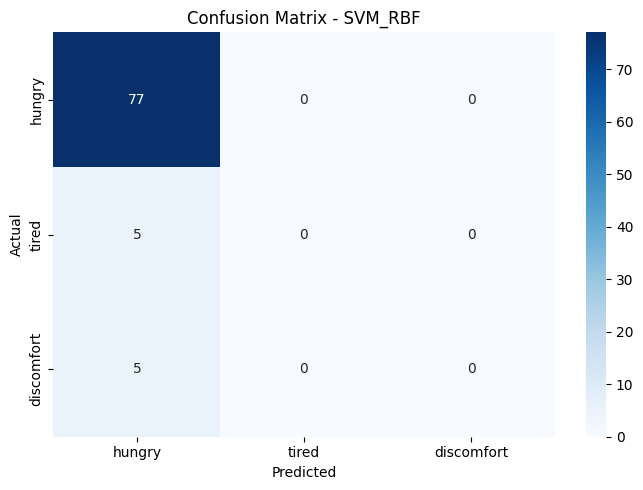

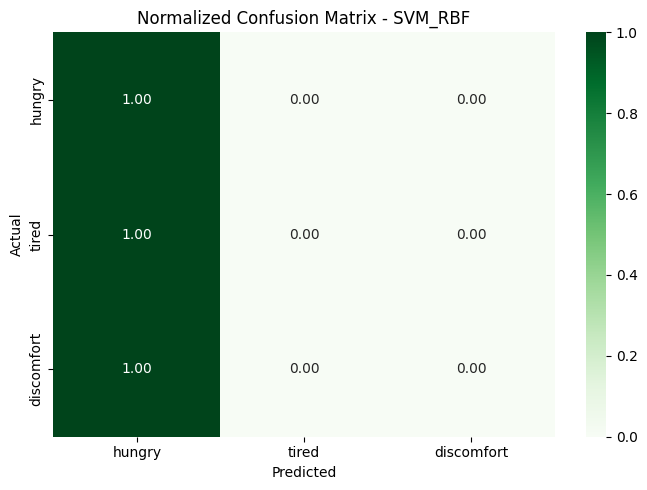

In [ ]:
cm = confusion_matrix(y_test, y_pred, labels=CLASS_NAMES)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)
plt.title(f"Confusion Matrix - {best_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

cm_norm = confusion_matrix(y_test, y_pred, labels=CLASS_NAMES, normalize="true")

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Greens",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)
plt.title(f"Normalized Confusion Matrix - {best_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# `10. Probability metrics / ROC-AUC (when supported)`

In [ ]:
auc_ovr = None
if hasattr(best_model, "predict_proba"):
    try:
        y_proba = best_model.predict_proba(X_test)
        y_test_encoded = pd.Categorical(y_test, categories=CLASS_NAMES).codes
        auc_ovr = roc_auc_score(
            y_test_encoded,
            y_proba,
            multi_class="ovr",
            average="macro",
            labels=list(range(len(CLASS_NAMES)))
        )
        print(f"Macro ROC-AUC (OvR): {auc_ovr:.4%}")
    except Exception as e:
        print("ROC-AUC could not be calculated:", repr(e))
else:
    print("Best model does not expose predict_proba().")

Macro ROC-AUC (OvR): 43.7282%


# `11. Feature importance / model interpretation`

In [ ]:
final_estimator = best_model.named_steps["model"]

# Map selected feature names if SelectKBest exists.
effective_features = FEATURE_NAMES

if "selector" in best_model.named_steps:
    selector = best_model.named_steps["selector"]
    mask = selector.get_support()
    effective_features = [f for f, keep in zip(FEATURE_NAMES, mask) if keep]

if hasattr(final_estimator, "feature_importances_"):
    importances = final_estimator.feature_importances_
    fi = (
        pd.DataFrame({
            "feature": effective_features,
            "importance": importances
        })
        .sort_values("importance", ascending=False)
        .head(20)
    )

    print("Top features:")
    display(fi)

    plt.figure(figsize=(8, 6))
    sns.barplot(data=fi, x="importance", y="feature")
    plt.title(f"Top Feature Importances - {best_name}")
    plt.tight_layout()
    plt.show()

elif hasattr(final_estimator, "coef_"):
    coef = np.mean(np.abs(final_estimator.coef_), axis=0)
    fi = (
        pd.DataFrame({
            "feature": effective_features,
            "importance": coef
        })
        .sort_values("importance", ascending=False)
        .head(20)
    )

    display(fi)

else:
    print("This model does not expose direct feature importance.")

This model does not expose direct feature importance.


# `12. Save the complete artifact as PKL`

In [ ]:
artifact = {
    "artifact_version": "1.1-3class",
    "task_mode": "3-class",
    "class_names": CLASS_NAMES,
    "target_column": TARGET_COLUMN,
    "feature_names": FEATURE_NAMES,
    "model_name": best_name,
    "pipeline": best_model,
    "training_notes": {
        "test_size": TEST_SIZE,
        "random_state": RANDOM_STATE,
        "cv_folds": CV_FOLDS,
        "imbalance_handler": "SMOTE or RandomOverSampler inside CV pipeline",
        "pre_extracted_features": True,
        "raw_audio_inference": "requires the same feature recipe/schema used by training"
    }
}

joblib.dump(artifact, MODEL_OUTPUT_PATH)

metrics = {
    "task_mode": "3-class",
    "model": best_name,
    "test_accuracy": float(test_accuracy),
    "test_balanced_accuracy": float(test_balanced_accuracy),
    "test_macro_precision": float(test_precision),
    "test_macro_recall": float(test_recall),
    "test_macro_f1": float(test_f1),
    "macro_roc_auc_ovr": None if auc_ovr is None else float(auc_ovr),
    "cv_summary": results_df[[
        "model", "cv_accuracy", "cv_balanced_accuracy", "cv_f1_macro"
    ]].to_dict(orient="records")
}

METRICS_OUTPUT_PATH.write_text(
    json.dumps(metrics, indent=2, ensure_ascii=False),
    encoding="utf-8"
)

print("Saved PKL :", MODEL_OUTPUT_PATH.resolve())
print("Saved JSON:", METRICS_OUTPUT_PATH.resolve())
print("PKL size  :", MODEL_OUTPUT_PATH.stat().st_size / 1024, "KB")

Saved PKL : /kaggle/working/smart_nursery_guardian_3class_best_model.pkl
Saved JSON: /kaggle/working/smart_nursery_guardian_3class_metrics.json
PKL size  : 91.49609375 KB



# `13. GUI Functions`

Recommended GUI flow:

`MP3/WAV -> audio preprocessing -> feature extraction -> saved PKL pipeline -> prediction + probability -> GUI message`.

The helper below therefore has two modes:
- `predict_feature_row(...)`: safest and immediately deployable with the pre-extracted feature schema.
- `predict_audio_file(...)`: attempts a standard audio-feature adapter and validates the resulting schema.

In [ ]:
def load_model_artifact(model_path="smart_nursery_guardian_best_model.pkl"):
    artifact = joblib.load(model_path)
    required = {"pipeline", "feature_names", "class_names", "model_name"}
    missing = required - set(artifact.keys())
    if missing:
        raise ValueError(f"Invalid model artifact. Missing keys: {missing}")
    return artifact

# `14. Predict directly from one pre-extracted feature row`

In [ ]:
def prepare_feature_row(feature_dict: Dict[str, Any], feature_names: List[str]) -> pd.DataFrame:
    row = pd.DataFrame([{f: feature_dict.get(f, np.nan) for f in feature_names}])
    row = row.replace([np.inf, -np.inf], np.nan)
    return row

def predict_feature_row(
    feature_dict: Dict[str, Any],
    artifact: Dict[str, Any]
) -> Dict[str, Any]:
    X_one = prepare_feature_row(
        feature_dict,
        artifact["feature_names"]
    )

    pipeline = artifact["pipeline"]
    pred = pipeline.predict(X_one)[0]

    result = {
        "label": str(pred),
        "model": artifact["model_name"]
    }

    if hasattr(pipeline, "predict_proba"):
        proba = pipeline.predict_proba(X_one)[0]
        classes = list(pipeline.classes_)
        probabilities = {
            str(cls): float(p)
            for cls, p in zip(classes, proba)
        }
        result["probabilities"] = probabilities
        result["confidence"] = float(np.max(proba))

    return result

# `15. extractstandard Audio Features`

In [ ]:
def extract_standard_audio_features(
    audio_path: str,
    sr: int = 22050,
    duration: float = 5.0,
    n_mfcc: int = 13
) -> Dict[str, float]:

    import librosa

    y_audio, loaded_sr = librosa.load(
        audio_path,
        sr=sr,
        mono=True,
        duration=duration
    )

    if y_audio is None or len(y_audio) == 0:
        raise ValueError("Audio file contains no readable samples.")

    # Force fixed duration for reproducibility.
    target_len = int(sr * duration)
    if len(y_audio) < target_len:
        y_audio = np.pad(y_audio, (0, target_len - len(y_audio)))
    else:
        y_audio = y_audio[:target_len]

    eps = 1e-10

    mfcc = librosa.feature.mfcc(y=y_audio, sr=sr, n_mfcc=n_mfcc)
    zcr = librosa.feature.zero_crossing_rate(y_audio)[0]
    rms = librosa.feature.rms(y=y_audio)[0]
    centroid = librosa.feature.spectral_centroid(y=y_audio, sr=sr)[0]
    bandwidth = librosa.feature.spectral_bandwidth(y=y_audio, sr=sr)[0]
    rolloff = librosa.feature.spectral_rolloff(y=y_audio, sr=sr)[0]

    feat = {}
    for i in range(n_mfcc):
        feat[f"mfcc_{i+1}_mean"] = float(np.mean(mfcc[i]))
        feat[f"mfcc_{i+1}_std"] = float(np.std(mfcc[i]) + eps)

    for name, arr in {
        "zcr": zcr,
        "rms": rms,
        "spectral_centroid": centroid,
        "spectral_bandwidth": bandwidth,
        "spectral_rolloff": rolloff,
    }.items():
        feat[f"{name}_mean"] = float(np.mean(arr))
        feat[f"{name}_std"] = float(np.std(arr) + eps)

    feat["duration_sec"] = float(len(y_audio) / sr)
    return feat

def predict_audio_file(
    audio_path: str,
    artifact: Dict[str, Any],
    sr: int = 22050,
    duration: float = 5.0,
    n_mfcc: int = 13
) -> Dict[str, Any]:

    feature_dict = extract_standard_audio_features(
        audio_path=audio_path,
        sr=sr,
        duration=duration,
        n_mfcc=n_mfcc
    )

    required = artifact["feature_names"]
    missing = [f for f in required if f not in feature_dict]

    if missing:
        raise ValueError(
            "Raw-audio feature schema does not match the training dataset. "
            f"Missing {len(missing)} training features, e.g. {missing[:10]}. "
            "Use the exact feature extraction recipe that created the "
            "pre-extracted dataset before deploying raw MP3/WAV inference."
        )

    return predict_feature_row(feature_dict, artifact)

# `16. GUI Result Mapping`

In [ ]:
DISPLAY_MESSAGES = {
    "hungry": "Hungry cry detected.",
    "tired": "Tired cry detected.",
    "discomfort": "Discomfort cry detected.",
}

def format_gui_prediction(result: Dict[str, Any]) -> str:
    label = result["label"]

    if label not in CLASS_NAMES:
        raise ValueError(
            f"Unexpected model label '{label}'. "
            f"This artifact is restricted to: {CLASS_NAMES}"
        )

    message = DISPLAY_MESSAGES[label]

    if "confidence" in result:
        return f"{message}\nConfidence: {result['confidence']:.1%}"

    return message


# `17. Quick single-file Prediction`


In [ ]:
artifact = load_model_artifact("smart-nursery-guardian-model.pkl")
result = predict_audio_file("assets/crying-audio.mp3", artifact)
print(format_gui_prediction(result))